In [44]:
import numpy as np
import pandas as pd
from sklearn .model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [45]:
data=pd.read_csv("IMDB Dataset.csv")

In [46]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [47]:
data['sentiment']=data['sentiment'].map({'positive':1,'negative':0})

In [48]:
X=data['review']
y=data['sentiment']

In [49]:
tokenizer=Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X)
X_seq=tokenizer.texts_to_sequences(X)


In [50]:
X_train,X_test,y_train,y_test=train_test_split(X_seq,y,test_size=0.2,random_state=42)

In [51]:
X_train=pad_sequences(X_train,maxlen=200)
X_test=pad_sequences(X_test,maxlen=200)

In [52]:
X_train=np.array(X_train).astype('int32')
X_test=np.array(X_test).astype('int32')
y_train=np.array(y_train).astype('int32')
y_test=np.array(y_test).astype('int32')

In [53]:
model=keras.Sequential([
    layers.Embedding(input_dim=10000,output_dim=128,input_length=200),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1,activation='sigmoid')
])
    

C:\Users\amanp\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [54]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
    

In [55]:
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [56]:
history=model.fit(
    X_train,y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.6373 - loss: 0.6678 - val_accuracy: 0.7730 - val_loss: 0.6045
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.7833 - loss: 0.5145 - val_accuracy: 0.8399 - val_loss: 0.4087
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.8470 - loss: 0.3763 - val_accuracy: 0.8658 - val_loss: 0.3296
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.8781 - loss: 0.3094 - val_accuracy: 0.8751 - val_loss: 0.2999
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.8928 - loss: 0.2777 - val_accuracy: 0.8838 - val_loss: 0.2809
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.8992 - loss: 0.2599 - val_accuracy: 0.8754 - val_loss: 0.2945
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.9113 - loss: 0.2405 - val_accuracy: 0.8838 - val_loss: 0.2804
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.9183 - loss: 0.2233 - val_accuracy: 0.8755 - v

In [57]:
loss,accuracy=model.evaluate(X_test,y_test)
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8842 - loss: 0.2734 
0.8841999769210815


In [58]:
predictions=model.predict(X_test[:5])
print(predictions)
predictions=(predictions>0.5).astype('int32')
print(y_test[:5])
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
[[0.04673598]
 [0.8808273 ]
 [0.03186462]
 [0.9802853 ]
 [0.03016337]]
[1 1 0 1 0]
[[0]
 [1]
 [0]
 [1]
 [0]]


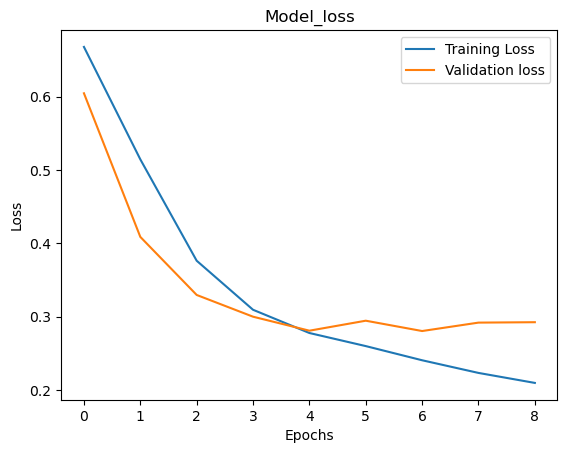

In [59]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Training Loss','Validation loss'])
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step   


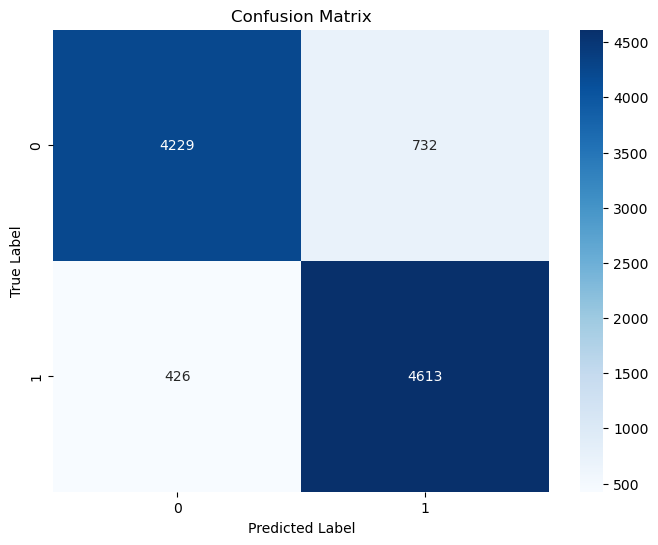

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()